In [25]:
import numpy as np
import pandas as pd
import netwulf as nw
import networkx as nx
import matplotlib.pyplot as plt
# from pyvis.network import Network

#https://netwulf.readthedocs.io/en/latest/python_api/post_back.html

In [26]:
# import sys
# print(sys.executable)
# print(sys.version)
# print(sys.version_info)

In [27]:
# !python3 -V

In [28]:
# !pip3 install netwulf
#!conda install --upgrade matplotlib

In [29]:
pd.set_option('display.max_rows', 500)

In [60]:
# 人数对应点的大小
# old code
# passenger_survey_pd = pd.read_csv('./static_data/passenger_survey.csv')
passenger_survey_pd = pd.read_csv('./graph_passenger_survey202411.csv')
passenger_survey_pd

,station_en,odpt:surveyYear,P_count,line,station_jp,next_station_en,next_station_jp,sta_long,sta_lat,next_sta_long,next_sta_lat,distance,degree,next_degree,sta_code,next_sta_code
0,Shibuya,2018,3813638,TokyoMetro.Ginza,渋谷,Omote-sando,表参道,139.701017,35.659299,139.711346,35.665652,1.170746,8,5,15,383
1,Shibuya,2018,3813638,Tokyu.DenEnToshi,渋谷,Ikejiriohashi,池尻大橋,139.701017,35.659299,139.683642,35.650526,1.848830,8,2,15,644
2,Shibuya,2018,3813638,Tokyu.Toyoko,渋谷,Daikan-yama,代官山,139.701017,35.659299,139.703084,35.648043,1.265864,8,2,15,1172
3,Shibuya,2018,3813638,TokyoMetro.Hanzomon,渋谷,Omote-sando,表参道,139.701017,35.659299,139.711346,35.665652,1.170746,8,5,15,383
4,Shibuya,2018,3813638,Keio.Inokashira,渋谷,Shinsen,神泉,139.701017,35.659299,139.693130,35.657170,0.751097,8,2,15,728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6982,Futomi,2018,63,JR-East.Uchibo,太海,Awa-Kamogawa,安房鴨川,140.096229,35.081435,140.103566,35.107465,2.971313,2,2,1218,1290
6983,Emi,2020,53,JR-East.Uchibo,江見,Futomi,太海,140.061026,35.062513,140.096229,35.081435,3.834008,2,2,227,1218
6984,Odaka,2016,26,JR-East.Joban,小高,Iwaki-Ota,磐城太田,140.996375,37.562980,140.991407,37.605114,4.706972,2,2,45,0
6985,Namie,2018,24,JR-East.Joban,浪江,Momouchi,桃内,140.989521,37.492291,140.984352,37.528660,4.070946,2,2,83,1179


In [31]:
passenger_survey_pd['line'].unique()

array(['TokyoMetro.Ginza', 'Tokyu.DenEnToshi', 'Tokyu.Toyoko',
       'TokyoMetro.Hanzomon', 'Keio.Inokashira', 'JR-East.SaikyoKawagoe',
       'JR-East.ShonanShinjuku', 'JR-East.Yamanote', 'Toei.Oedo',
       'Toei.Shinjuku', 'TokyoMetro.Marunouchi', 'Keio.KeioNew',
       'Keio.Keio', 'JR-East.ChuoRapid', 'JR-East.ChuoSobuLocal',
       'TokyoMetro.Fukutoshin', 'TokyoMetro.Yurakucho', 'Tobu.Tojo',
       'Seibu.Ikebukuro', 'Keikyu.Main', 'Sotetsu.Main',
       'YokohamaMunicipal.Blue', 'JR-East.KeihinTohokuNegishi',
       'JR-East.Tokaido', 'JR-East.Yokosuka', 'TokyoMetro.Tozai',
       'Seibu.Shinjuku', 'JR-East.JobanRapid', 'JR-East.Keiyo',
       'JR-East.SobuRapid', 'JR-East.Takasaki', 'JR-East.Utsunomiya',
       'Toei.Asakusa', 'Yurikamome.Yurikamome', 'Toei.Mita',
       'Tokyu.Meguro', 'TokyoMetro.Namboku', 'TokyoMetro.Chiyoda',
       'JR-East.JobanLocal', 'TokyoMetro.Hibiya', 'Tokyu.Ikegami',
       'Tokyu.Oimachi', 'TWR.Rinkai', 'Tobu.TobuUrbanPark',
       'Toei.NipporiT

In [61]:
passenger_survey_pd.loc[passenger_survey_pd['line']=='TokyoMetro.Marunouchi']

,station_en,odpt:surveyYear,P_count,line,station_jp,next_station_en,next_station_jp,sta_long,sta_lat,next_sta_long,next_sta_lat,distance,degree,next_degree,sta_code,next_sta_code
66,Shinjuku,2018,2284184,TokyoMetro.Marunouchi,新宿,Shinjuku-sanchome,新宿三丁目,139.699019,35.688462,139.706794,35.691016,0.757663,12,5,617,1297
76,Shinjuku,2019,2258687,TokyoMetro.Marunouchi,新宿,Shinjuku-sanchome,新宿三丁目,139.699019,35.688462,139.706794,35.691016,0.757663,12,5,617,1297
86,Shinjuku,2017,2245747,TokyoMetro.Marunouchi,新宿,Shinjuku-sanchome,新宿三丁目,139.699019,35.688462,139.706794,35.691016,0.757663,12,5,617,1297
96,Shinjuku,2016,1772934,TokyoMetro.Marunouchi,新宿,Shinjuku-sanchome,新宿三丁目,139.699019,35.688462,139.706794,35.691016,0.757663,12,5,617,1297
162,Shinjuku,2020,1435065,TokyoMetro.Marunouchi,新宿,Shinjuku-sanchome,新宿三丁目,139.699019,35.688462,139.706794,35.691016,0.757663,12,5,617,1297
193,Shinjuku,2015,991383,TokyoMetro.Marunouchi,新宿,Shinjuku-sanchome,新宿三丁目,139.699019,35.688462,139.706794,35.691016,0.757663,12,5,617,1297
203,Shinjuku,2013,978384,TokyoMetro.Marunouchi,新宿,Shinjuku-sanchome,新宿三丁目,139.699019,35.688462,139.706794,35.691016,0.757663,12,5,617,1297
213,Shinjuku,2014,974891,TokyoMetro.Marunouchi,新宿,Shinjuku-sanchome,新宿三丁目,139.699019,35.688462,139.706794,35.691016,0.757663,12,5,617,1297
264,Tokyo,2018,685440,TokyoMetro.Marunouchi,東京,Otemachi,大手町,139.764800,35.681935,139.762798,35.684093,0.300553,8,9,176,786
281,Tokyo,2019,679338,TokyoMetro.Marunouchi,東京,Otemachi,大手町,139.764800,35.681935,139.762798,35.684093,0.300553,8,9,176,786


In [62]:
passenger_survey_pd.loc[passenger_survey_pd['line']=='TokyoMetro.MarunouchiBranch']

,station_en,odpt:surveyYear,P_count,line,station_jp,next_station_en,next_station_jp,sta_long,sta_lat,next_sta_long,next_sta_lat,distance,degree,next_degree,sta_code,next_sta_code
3005,Honancho,2019,39769,TokyoMetro.MarunouchiBranch,方南町,Nakano-fujimicho,中野富士見町,139.657935,35.683515,139.666933,35.690514,1.125553,1,2,187,534
3096,Honancho,2018,38064,TokyoMetro.MarunouchiBranch,方南町,Nakano-fujimicho,中野富士見町,139.657935,35.683515,139.666933,35.690514,1.125553,1,2,187,534
3147,Honancho,2017,37224,TokyoMetro.MarunouchiBranch,方南町,Nakano-fujimicho,中野富士見町,139.657935,35.683515,139.666933,35.690514,1.125553,1,2,187,534
3184,Honancho,2016,36335,TokyoMetro.MarunouchiBranch,方南町,Nakano-fujimicho,中野富士見町,139.657935,35.683515,139.666933,35.690514,1.125553,1,2,187,534
3226,Honancho,2015,35001,TokyoMetro.MarunouchiBranch,方南町,Nakano-fujimicho,中野富士見町,139.657935,35.683515,139.666933,35.690514,1.125553,1,2,187,534
3276,Honancho,2014,33904,TokyoMetro.MarunouchiBranch,方南町,Nakano-fujimicho,中野富士見町,139.657935,35.683515,139.666933,35.690514,1.125553,1,2,187,534
3292,Honancho,2013,33335,TokyoMetro.MarunouchiBranch,方南町,Nakano-fujimicho,中野富士見町,139.657935,35.683515,139.666933,35.690514,1.125553,1,2,187,534
3448,Honancho,2020,30412,TokyoMetro.MarunouchiBranch,方南町,Nakano-fujimicho,中野富士見町,139.657935,35.683515,139.666933,35.690514,1.125553,1,2,187,534


In [63]:
passenger_survey_pd[passenger_survey_pd['P_count'] > 500000]['station_en'].unique()

array(['Shibuya', 'Shinjuku', 'Ikebukuro', 'Yokohama', 'Takadanobaba',
       'Tokyo', 'Shimbashi', 'Meguro', 'Shinagawa'], dtype=object)

In [64]:
passenger_survey_pd[passenger_survey_pd['station_en'] == 'Shibuya']['P_count'].mean()

3392235.625

In [36]:
# 边需要清洗
station_node_pd = pd.read_csv('./line_station_connectionV1130.csv')
station_node_pd = station_node_pd[['line', 'station_name1', 'station_name2', 'distance']]
station_node_pd

,line,station_name1,station_name2,distance
0,JR-East.Yamanote,大崎,五反田,0.735128
1,JR-East.Yamanote,五反田,目黒,1.120418
2,JR-East.Yamanote,目黒,恵比寿,1.254671
3,JR-East.Yamanote,恵比寿,渋谷,1.425703
4,JR-East.Yamanote,渋谷,原宿,1.009891
...,...,...,...,...
1489,YokohamaMunicipal.Green,センター北,北山田,1.669461
1490,YokohamaMunicipal.Green,北山田,東山田,1.463786
1491,YokohamaMunicipal.Green,東山田,高田,1.774937
1492,YokohamaMunicipal.Green,高田,日吉本町,1.513431


In [37]:
station_node_pd

,line,station_name1,station_name2,distance
0,JR-East.Yamanote,大崎,五反田,0.735128
1,JR-East.Yamanote,五反田,目黒,1.120418
2,JR-East.Yamanote,目黒,恵比寿,1.254671
3,JR-East.Yamanote,恵比寿,渋谷,1.425703
4,JR-East.Yamanote,渋谷,原宿,1.009891
...,...,...,...,...
1489,YokohamaMunicipal.Green,センター北,北山田,1.669461
1490,YokohamaMunicipal.Green,北山田,東山田,1.463786
1491,YokohamaMunicipal.Green,東山田,高田,1.774937
1492,YokohamaMunicipal.Green,高田,日吉本町,1.513431


In [ ]:
# 先用networkx建立一个graph结构 
G = nx.Graph()
G = nx.from_pandas_edgelist(station_node_pd, 'station_name1', 'station_name2', edge_attr=True)

(<Figure size 480x480 with 1 Axes>, <Axes: >)

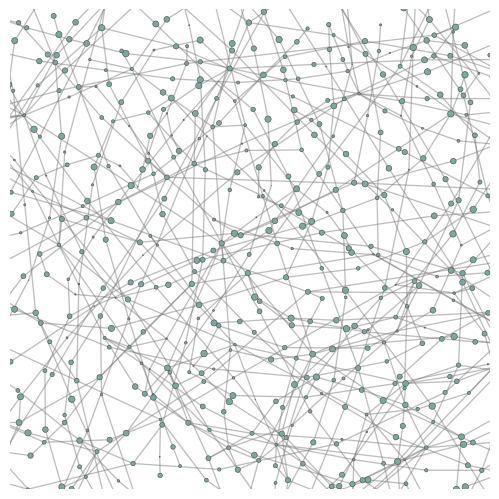

In [39]:
for n, data in G.nodes(data=True):
    data['size'] = np.random.random()

stylized_network, config = nw.visualize(G, plot_in_cell_below=True)

nw.draw_netwulf(stylized_network, config)
#Once you’re done, press the button Post to Python.

In [40]:
config

{'zoom': 1,
 'node_charge': -45,
 'node_gravity': 0.1,
 'link_distance': 15,
 'link_distance_variation': 0,
 'node_collision': True,
 'wiggle_nodes': False,
 'freeze_nodes': False,
 'node_fill_color': '#79aaa0',
 'node_stroke_color': '#555555',
 'node_label_color': '#000000',
 'display_node_labels': False,
 'scale_node_size_by_strength': False,
 'node_size': 5,
 'node_stroke_width': 1,
 'node_size_variation': 0.5,
 'link_color': '#7c7c7c',
 'link_width': 2,
 'link_alpha': 0.5,
 'link_width_variation': 0.5,
 'display_singleton_nodes': True,
 'min_link_weight_percentile': 0,
 'max_link_weight_percentile': 1}

In [41]:
station_node_pd[(station_node_pd['station_name1'] == '前橋大島') & (station_node_pd['station_name2'] == '前橋')]

,line,station_name1,station_name2,distance


In [42]:
stylized_network

{'xlim': [0, 742],
 'ylim': [0, 742],
 'linkColor': '#7c7c7c',
 'linkAlpha': 0.5,
 'nodeStrokeColor': '#555555',
 'nodeStrokeWidth': 1,
 'links': [{'source': '大崎', 'target': '五反田', 'width': 2, 'weight': 1},
  {'source': '大崎', 'target': '品川', 'width': 2, 'weight': 1},
  {'source': '大崎', 'target': '恵比寿', 'width': 2, 'weight': 1},
  {'source': '大崎', 'target': '西大井', 'width': 2, 'weight': 1},
  {'source': '大崎', 'target': '大井町', 'width': 2, 'weight': 1},
  {'source': '五反田', 'target': '目黒', 'width': 2, 'weight': 1},
  {'source': '五反田', 'target': '大崎広小路', 'width': 2, 'weight': 1},
  {'source': '五反田', 'target': '戸越', 'width': 2, 'weight': 1},
  {'source': '五反田', 'target': '高輪台', 'width': 2, 'weight': 1},
  {'source': '目黒', 'target': '恵比寿', 'width': 2, 'weight': 1},
  {'source': '目黒', 'target': '不動前', 'width': 2, 'weight': 1},
  {'source': '目黒', 'target': '白金台', 'width': 2, 'weight': 1},
  {'source': '恵比寿', 'target': '渋谷', 'width': 2, 'weight': 1},
  {'source': '恵比寿', 'target': '広尾', 'width': 2

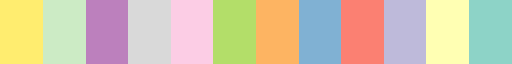

In [43]:
plt.get_cmap("Set3_r")

In [44]:
# line_color

In [45]:
d_max = station_node_pd['distance'].max()
station_node_pd['nor_distance'] = station_node_pd['distance'].apply(lambda x: (x - 0.1) / (d_max - 0.1))

In [46]:
station_node_pd['operator'] = station_node_pd['line'].apply(lambda x: x.split('.')[0])
station_node_pd

,line,station_name1,station_name2,distance,nor_distance,operator
0,JR-East.Yamanote,大崎,五反田,0.735128,0.048421,JR-East
1,JR-East.Yamanote,五反田,目黒,1.120418,0.077795,JR-East
2,JR-East.Yamanote,目黒,恵比寿,1.254671,0.088030,JR-East
3,JR-East.Yamanote,恵比寿,渋谷,1.425703,0.101069,JR-East
4,JR-East.Yamanote,渋谷,原宿,1.009891,0.069368,JR-East
...,...,...,...,...,...,...
1489,YokohamaMunicipal.Green,センター北,北山田,1.669461,0.119653,YokohamaMunicipal
1490,YokohamaMunicipal.Green,北山田,東山田,1.463786,0.103972,YokohamaMunicipal
1491,YokohamaMunicipal.Green,東山田,高田,1.774937,0.127694,YokohamaMunicipal
1492,YokohamaMunicipal.Green,高田,日吉本町,1.513431,0.107757,YokohamaMunicipal


In [47]:
operators_list = station_node_pd['operator'].unique()
operators_list.sort()
operators_list

array(['Hokuso', 'JR-East', 'Keikyu', 'Keio', 'Keisei', 'Minatomirai',
       'Odakyu', 'SaitamaRailway', 'Seibu', 'Shibayama', 'ShinKeisei',
       'Sotetsu', 'TWR', 'Tobu', 'Toei', 'TokyoMetro', 'TokyoMonorail',
       'Tokyu', 'ToyoRapid', 'YokohamaMunicipal', 'Yurikamome'],
      dtype=object)

In [48]:
station_node_pd[station_node_pd['distance'] > 100]

,line,station_name1,station_name2,distance,nor_distance,operator


In [ ]:
# 根据不同的线路添加不同的颜色
# 先定义一个好看的 
# colors = range(len(station_node_pd['line'].unique()))
colors = range(len(station_node_pd['operator'].unique()))
N=len(colors)

cmap = plt.get_cmap("Set3_r")
cmap_list=[]
for i in range(N):
    c=cmap(float(i)/N)
    cmap_list.append(c)

line_color=dict(zip(operators_list,cmap_list))

line_color

{'Hokuso': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0),
 'JR-East': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0),
 'Keikyu': (0.8, 0.9215686274509803, 0.7725490196078432, 1.0),
 'Keio': (0.8, 0.9215686274509803, 0.7725490196078432, 1.0),
 'Keisei': (0.7372549019607844, 0.5019607843137255, 0.7411764705882353, 1.0),
 'Minatomirai': (0.7372549019607844,
  0.5019607843137255,
  0.7411764705882353,
  1.0),
 'Odakyu': (0.8509803921568627, 0.8509803921568627, 0.8509803921568627, 1.0),
 'SaitamaRailway': (0.9882352941176471,
  0.803921568627451,
  0.8980392156862745,
  1.0),
 'Seibu': (0.9882352941176471, 0.803921568627451, 0.8980392156862745, 1.0),
 'Shibayama': (0.7019607843137254,
  0.8705882352941177,
  0.4117647058823529,
  1.0),
 'ShinKeisei': (0.7019607843137254,
  0.8705882352941177,
  0.4117647058823529,
  1.0),
 'Sotetsu': (0.9921568627450981, 0.7058823529411765, 0.3843137254901961, 1.0),
 'TWR': (0.9921568627450981, 0.7058823529411765, 0.3843137254901961, 1.0),
 'Tobu

In [ ]:
# stylized_network

In [ ]:
# 总之先试着改一下试试
# 看上去没问题，那就先生成一个cmap，然后为每个edge添加 
for link in stylized_network['links']:
    line = station_node_pd[((station_node_pd['station_name1'] == link['source']) & (station_node_pd['station_name2'] == link['target'])) |
                           ((station_node_pd['station_name1'] == link['target']) & (station_node_pd['station_name2'] == link['source']))]

    if len(line) > 0:
        #print(line)#operator
        #link['color'] = line_color[line.iloc[0, 4]]
        link['color'] = line_color[line.iloc[0, 5]]
        dis = line.iloc[0, 3]
        if dis < 1.0:
            link['width'] = 5
        elif dis < 2.0:
            link['width'] = 4
        elif dis < 5.0:
            link['width'] = 3
        elif dis < 10.0:
            link['width'] = 2
        else:
            link['width'] = 1
#     else:
#         print(link)

In [52]:
for node in stylized_network['nodes']:
    sta = passenger_survey_pd[passenger_survey_pd['station_en'] == node['id']]
    if len(sta) > 0:
        #node['color'] = line_color[station_node_pd[station_node_pd['station_en'] == node['id']].iloc[0, 4]]
        node['color'] = line_color[station_node_pd[station_node_pd['station_en'] == node['id']].iloc[0, 5]]
        if sta['P_count'].mean() < 10000:
            node['radius'] = 1.5
        elif sta['P_count'].mean() < 100000:
            node['radius'] = 2.5
        elif sta['P_count'].mean() < 500000:
            node['radius'] = 4
        elif sta['P_count'].mean() < 1000000:
            node['radius'] = 7
        elif sta['P_count'].mean() < 2000000:
            node['radius'] = 9
        else:
            node['radius'] = 10
    if node['id'] in ['Shibuya', 'Shinjuku', 'Ikebukuro', 'Yokohama', 'Takadanobaba', 'Tokyo', 'Shimbashi', 'Shinagawa']:
        node['color'] = "lawngreen"

In [ ]:
# stylized_network[]

(<Figure size 480x480 with 1 Axes>, <Axes: >)

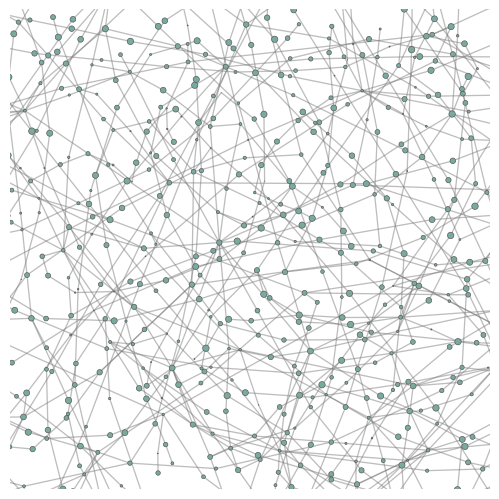

In [54]:
stylized_network, config = nw.visualize(G, plot_in_cell_below=True)
nw.draw_netwulf(stylized_network, config)

In [55]:
# 调颜色
# 点的大小（按利用人数决定size/颜色待定）
# Rifu, Morioka需要去掉
# 线的粗细再强调一下,调整alpha
#fig, ax = nw.draw_netwulf(stylized_network, config, figsize=12)
# nw.visualize(stylized_network, plot_in_cell_below=True)
nw.visualize(stylized_network)

({'xlim': [0, 742],
  'ylim': [0, 742],
  'linkColor': '#7c7c7c',
  'linkAlpha': 0.5,
  'nodeStrokeColor': '#555555',
  'nodeStrokeWidth': 1,
  'links': [{'source': '大崎', 'target': '五反田', 'width': 2, 'weight': 1},
   {'source': '大崎', 'target': '品川', 'width': 2, 'weight': 1},
   {'source': '大崎', 'target': '恵比寿', 'width': 2, 'weight': 1},
   {'source': '大崎', 'target': '西大井', 'width': 2, 'weight': 1},
   {'source': '大崎', 'target': '大井町', 'width': 2, 'weight': 1},
   {'source': '五反田', 'target': '目黒', 'width': 2, 'weight': 1},
   {'source': '五反田', 'target': '大崎広小路', 'width': 2, 'weight': 1},
   {'source': '五反田', 'target': '戸越', 'width': 2, 'weight': 1},
   {'source': '五反田', 'target': '高輪台', 'width': 2, 'weight': 1},
   {'source': '目黒', 'target': '恵比寿', 'width': 2, 'weight': 1},
   {'source': '目黒', 'target': '不動前', 'width': 2, 'weight': 1},
   {'source': '目黒', 'target': '白金台', 'width': 2, 'weight': 1},
   {'source': '恵比寿', 'target': '渋谷', 'width': 2, 'weight': 1},
   {'source': '恵比寿', 'targe

In [ ]:
# stylized_network['linkAlpha'] = 1
# stylized_network, config = nw.visualize(stylized_network, plot_in_cell_below=True)

In [ ]:
# stylized_network

In [ ]:
config

{'zoom': 1,
 'node_charge': -45,
 'node_gravity': 0.1,
 'link_distance': 15,
 'link_distance_variation': 0,
 'node_collision': True,
 'wiggle_nodes': False,
 'freeze_nodes': False,
 'node_fill_color': '#79aaa0',
 'node_stroke_color': '#555555',
 'node_label_color': '#000000',
 'display_node_labels': False,
 'scale_node_size_by_strength': False,
 'node_size': 5,
 'node_stroke_width': 1,
 'node_size_variation': 0.5,
 'link_color': '#7c7c7c',
 'link_width': 2,
 'link_alpha': 0.5,
 'link_width_variation': 0.5,
 'display_singleton_nodes': True,
 'min_link_weight_percentile': 0,
 'max_link_weight_percentile': 1}

In [ ]:
stylized_network

{'xlim': [0, 885],
 'ylim': [0, 885],
 'linkColor': '#7c7c7c',
 'linkAlpha': 0.5,
 'nodeStrokeColor': '#555555',
 'nodeStrokeWidth': 1,
 'links': [{'source': 'Shinonome',
   'target': 'Kokusai-tenjijo',
   'width': 2,
   'weight': 1},
  {'source': 'Shinonome', 'target': 'Shin-kiba', 'width': 2, 'weight': 1},
  {'source': 'Kokusai-tenjijo',
   'target': 'Tokyo Teleport',
   'width': 2,
   'weight': 1},
  {'source': 'Ochiai', 'target': 'Takadanobaba', 'width': 2, 'weight': 1},
  {'source': 'Ochiai', 'target': 'Nakano', 'width': 2, 'weight': 1},
  {'source': 'Takadanobaba', 'target': 'Waseda', 'width': 2, 'weight': 1},
  {'source': 'Takadanobaba',
   'target': 'Shimo-Ochiai',
   'width': 2,
   'weight': 1},
  {'source': 'Takadanobaba', 'target': 'Mejiro', 'width': 2, 'weight': 1},
  {'source': 'Takadanobaba', 'target': 'Shin-Okubo', 'width': 2, 'weight': 1},
  {'source': 'Takadanobaba',
   'target': 'Seibu-Shinjuku',
   'width': 2,
   'weight': 1},
  {'source': 'Nisshin', 'target': 'Nishi

In [56]:
len(stylized_network['links'])

1299

In [57]:
for sta in passenger_survey_pd[passenger_survey_pd['P_count'] > 500000].groupby(by='station_en'):
    print(sta[0] + ': {}'.format(sta[1]['P_count'].mean()))

Ikebukuro: 1574140.375
Meguro: 619188.3333333334
Shibuya: 3392235.625
Shimbashi: 583241.2
Shinagawa: 524169.0
Shinjuku: 1617659.375
Takadanobaba: 702770.7142857143
Tokyo: 643634.7142857143
Yokohama: 1027686.75


In [58]:
nw.visualize(stylized_network, plot_in_cell_below=True)

({'xlim': [0, 742],
  'ylim': [0, 742],
  'linkColor': '#7c7c7c',
  'linkAlpha': 0.5,
  'nodeStrokeColor': '#555555',
  'nodeStrokeWidth': 1,
  'links': [{'source': '大崎', 'target': '五反田', 'width': 2, 'weight': 1},
   {'source': '大崎', 'target': '品川', 'width': 2, 'weight': 1},
   {'source': '大崎', 'target': '恵比寿', 'width': 2, 'weight': 1},
   {'source': '大崎', 'target': '西大井', 'width': 2, 'weight': 1},
   {'source': '大崎', 'target': '大井町', 'width': 2, 'weight': 1},
   {'source': '五反田', 'target': '目黒', 'width': 2, 'weight': 1},
   {'source': '五反田', 'target': '大崎広小路', 'width': 2, 'weight': 1},
   {'source': '五反田', 'target': '戸越', 'width': 2, 'weight': 1},
   {'source': '五反田', 'target': '高輪台', 'width': 2, 'weight': 1},
   {'source': '目黒', 'target': '恵比寿', 'width': 2, 'weight': 1},
   {'source': '目黒', 'target': '不動前', 'width': 2, 'weight': 1},
   {'source': '目黒', 'target': '白金台', 'width': 2, 'weight': 1},
   {'source': '恵比寿', 'target': '渋谷', 'width': 2, 'weight': 1},
   {'source': '恵比寿', 'targe

In [59]:
# Create a network
test_G = nx.random_partition_graph([10, 10, 10], .25, .01)

# Change 'block' node attribute to 'group'
for k, v in test_G.nodes(data=True):
    v['group'] = v['block']; del v['block']

# Or detect communities and encode them in 'group' attribute
# import community
# bb = community.best_partition(G)
# nx.set_node_attributes(G, bb, 'group')

# Set node 'size' attributes
for n, data in test_G.nodes(data=True):
    data['size'] = np.random.random()

# Set link 'weight' attributes
for n1, n2, data in test_G.edges(data=True):
    data['weight'] = np.random.random()

test_return, tesy_config = nw.visualize(test_G)

In [ ]:
station_node_pd[station_node_pd['station_en'] == 'Kokusai-tenjijo']

,line,station_en,next_station_en,distance,nor_distance,operator
382,TWR.Rinkai,Kokusai-tenjijo,Tokyo Teleport,1.381395,0.008371,TWR


Shibuya {'size': 10}


({'xlim': [0, 885],
  'ylim': [0, 885],
  'linkColor': '#7c7c7c',
  'linkAlpha': 0.5,
  'nodeStrokeColor': '#555555',
  'nodeStrokeWidth': 2.2909078778325744,
  'links': [{'source': 'Shinonome',
    'target': 'Kokusai-tenjijo',
    'width': 1.284452939868071,
    'weight': 1},
   {'source': 'Shinonome',
    'target': 'Shin-kiba',
    'width': 1.284452939868071,
    'weight': 1},
   {'source': 'Kokusai-tenjijo',
    'target': 'Tokyo Teleport',
    'width': 1.284452939868071,
    'weight': 1},
   {'source': 'Ochiai',
    'target': 'Takadanobaba',
    'width': 1.284452939868071,
    'weight': 1},
   {'source': 'Ochiai',
    'target': 'Nakano',
    'width': 1.284452939868071,
    'weight': 1},
   {'source': 'Takadanobaba',
    'target': 'Waseda',
    'width': 1.284452939868071,
    'weight': 1},
   {'source': 'Takadanobaba',
    'target': 'Shimo-Ochiai',
    'width': 1.284452939868071,
    'weight': 1},
   {'source': 'Takadanobaba',
    'target': 'Mejiro',
    'width': 1.284452939868071,
 

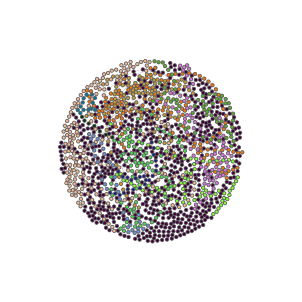

In [ ]:
test_G = nx.Graph()
test_G = nx.from_pandas_edgelist(station_node_pd, 'station_en', 'next_station_en', edge_attr=True)

for k, v in test_G.nodes(data=True):
    v['group'] = line_color[station_node_pd[(station_node_pd['station_en'] == k) | (station_node_pd['next_station_en'] == k)].iloc[0, 5]]

for n, data in G.nodes(data=True):
    sta = passenger_survey_pd[passenger_survey_pd['station_en'] == n]
    if len(sta) > 0:
        if sta['P_count'].mean() < 10000:
            data['size'] = 1
        elif sta['P_count'].mean() < 100000:
            data['size'] = 2
        elif sta['P_count'].mean() < 500000:
            data['size'] = 3
        else:
            data['size'] = 5
    if n == 'Shibuya':
        data['size'] = 10
        print(n, data)
nw.visualize(test_G)

In [ ]:
passenger_survey_pd[passenger_survey_pd['station_en'] == 'Shibuya']

In [ ]:
passenger_survey_pd[passenger_survey_pd['station_en'] == 'Shinjuku']

In [ ]:
nw.visualize(test_G, plot_in_cell_below=True)

In [ ]:
passenger_survey_pd.sort_values(by='P_count')